In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/051_seydisfjordur/results/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 6)


,31,32,33,34,35,36
ENSG00000000003.15,0.017620,0.038303,0.035076,0.124942,0.000000,0.000000
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,122.063528,121.952084,109.225612,110.258314,113.841644,102.765415
ENSG00000000457.14,11.466005,10.464852,10.690215,8.491932,10.346185,10.297210
ENSG00000000460.17,21.985690,27.316227,28.533426,21.664120,29.360630,27.402752
...,...,...,...,...,...,...
ENSG00000291297.1,3.383728,5.673670,7.269850,9.605994,12.175889,12.022836
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,2.777067,3.543078,4.723128,3.456740,0.743401,5.417379
ENSG00000291300.1,0.226304,0.069284,0.020623,0.000000,0.000000,0.526862


In [6]:
for element in expression.columns:
    print(element)

31
32
33
34
35
36


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(14747, 6)
(1769, 6)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.39560388 0.23268184]


31
32
33
34
35
36


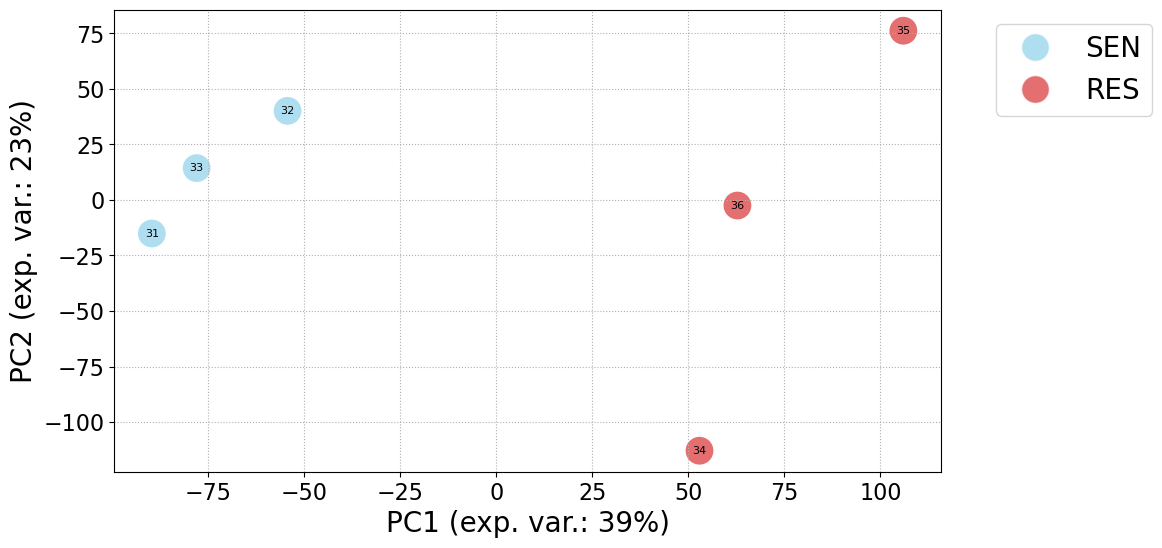

In [10]:
for i in range(len(new)):

    # colors
    rank = int(expression.columns[i])
    print(rank)
    
    if rank < 34:
        the_color = 'skyblue'
    else:
        the_color = 'tab:red'
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, rank, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    
]

matplotlib.pyplot.legend(legend_elements, ['SEN', 'RES'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.42145782 0.25518739]


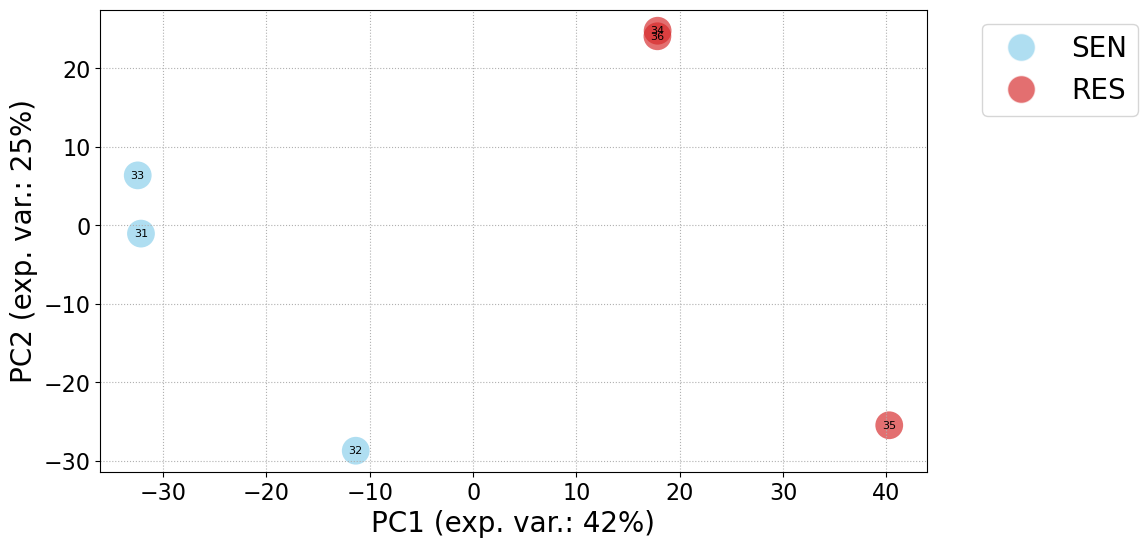

In [16]:
for i in range(len(new)):

    # colors
    rank = int(expression.columns[i])
    
    if rank < 34:
        the_color = 'skyblue'
    else:
        the_color = 'tab:red'
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, rank, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    
]

matplotlib.pyplot.legend(legend_elements, ['SEN', 'RES'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

In [13]:
# 5. distributions

In [14]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,31,32,33,34,35,36
ENSG00000000003.15,0.025198,0.054227,0.049737,0.169851,0.000000,0.000000
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,6.943259,6.941952,6.784316,6.797769,6.843502,6.697182
ENSG00000000457.14,3.639927,3.519146,3.547230,3.246702,3.504135,3.497895
ENSG00000000460.17,4.522664,4.823557,4.884277,4.502338,4.924130,4.827959


144
14.332363989576265


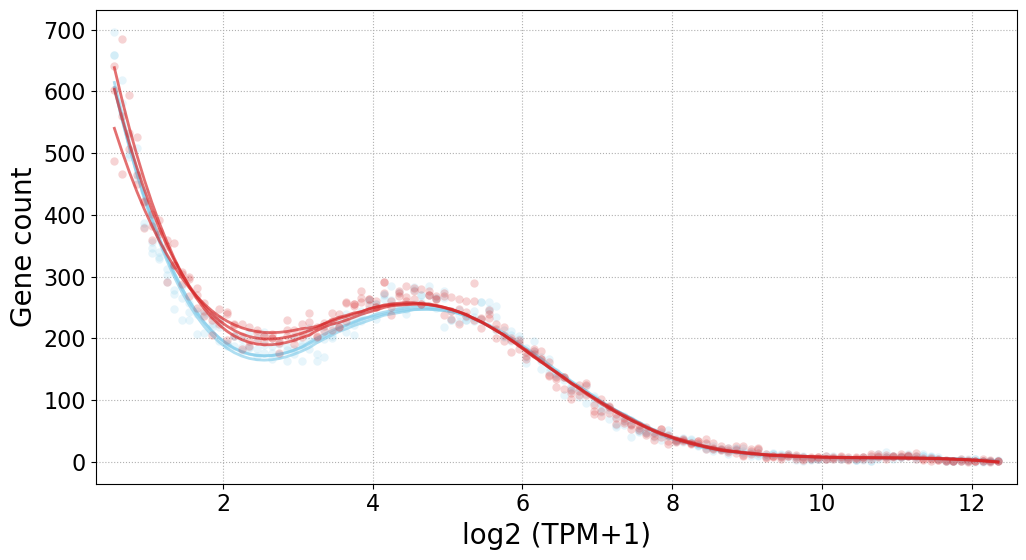

In [28]:
found_max = 14.4
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    sample = working_samples[i]
    rank = int(sample)

    if rank < 34:
        the_color = 'skyblue'
    else:
        the_color = 'tab:red'
    
    log2TPM = log2_tpm_PO.loc[:, sample]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
#matplotlib.pyplot.ylim([0, 400])

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)